In [81]:
import pandas as pd 
import numpy as np
import time
from PIL import Image

import altair as alt
import seaborn as sns
import matplotlib.pyplot as plt 

In [82]:
df1 = pd.read_csv("/Users/joshuakim/Desktop/Python Data/project 1 data/seoul_real_estate_dataset/2018.csv", encoding="euc-kr",low_memory = False)
df2 = pd.read_csv("/Users/joshuakim/Desktop/Python Data/project 1 data/seoul_real_estate_dataset/2019.csv", encoding="euc-kr",low_memory = False)
df3 = pd.read_csv("/Users/joshuakim/Desktop/Python Data/project 1 data/seoul_real_estate_dataset/2020.csv", encoding="euc-kr",low_memory = False)
df4 = pd.read_csv("/Users/joshuakim/Desktop/Python Data/project 1 data/seoul_real_estate_dataset/2021.csv", encoding="euc-kr",low_memory = False)
df5 = pd.read_csv("/Users/joshuakim/Desktop/Python Data/project 1 data/seoul_real_estate_dataset/2022.csv", encoding="euc-kr",low_memory = False) 
df6 = pd.read_csv("/Users/joshuakim/Desktop/Python Data/project 1 data/seoul_real_estate_dataset/2023.csv", encoding="euc-kr",low_memory = False)
df7 = pd.read_csv("/Users/joshuakim/Desktop/Python Data/project 1 data/seoul_real_estate_dataset/2024.csv", encoding="euc-kr",low_memory = False)

In [83]:
# 시각화시 한국어 안깨지게 하는 방법 
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False 

In [84]:
# 모든 데이터를 dfs 하나의 리스트로 만든 후 데이터 크기 측정

dfs = [df1, df2, df3, df4, df5, df6, df7]
df_all = pd.concat(dfs, axis=0, ignore_index=True, join = 'inner')
print(df_all.shape)

(833614, 21)


In [85]:
# 거래 취소건 데이터에서 제거
# 제거후 데이터 크기
df_all = df_all[df_all["취소일"].isna()]
print("거래 취소 건 제거 후:", df_all.shape)

거래 취소 건 제거 후: (808073, 21)


In [86]:
# 건축연도 정제 및 정제 후 데이터 크기

df_all = df_all.copy()
df_all["건축년도"] = pd.to_numeric(df_all["건축년도"], errors="coerce")
current_year = pd.Timestamp.today().year

df_all = df_all[(df_all["건축년도"] >= 1900) & (df_all["건축년도"] <= current_year)]
print("건축연도 정제 후:", df_all.shape)

건축연도 정제 후: (797441, 21)


In [87]:
# 건물 
df_all["건물면적(㎡)"] = pd.to_numeric(df_all["건물면적(㎡)"], errors="coerce")

# 평수 및 평수당 가격 구하기
df_all["평수"] = df_all["건물면적(㎡)"] / 3.3
df_all["평당가격"] = df_all["물건금액(만원)"] / df_all["평수"]

# print(df_all[["건물면적(㎡)", "평수", "물건금액(만원)", "평당가격"]]

# 연도별 평균 평당 가격
avg_py_year = (df_all.groupby("접수연도")["평당가격"].mean().reset_index())
avg_py_year["평당가격"] = avg_py_year["평당가격"].round(2)

print(avg_py_year)

   접수연도     평당가격
0  2018  2371.04
1  2019  2793.40
2  2020  2923.07
3  2021  3176.23
4  2022  3115.02
5  2023  3726.05
6  2024  4126.40


In [88]:
# 서울시장 분석에 필요한 값들 구하기 

# 연도별 평균 매매가격
seoul_year_price = (df_all.groupby("접수연도")["물건금액(만원)"].mean().reset_index().sort_values("접수연도"))

# 연도별 평균 평당가격
seoul_year_py = (df_all.groupby("접수연도")["평당가격"].mean().reset_index().sort_values("접수연도"))

# 연도별 거래량
seoul_year_volume = (df_all.groupby("접수연도").size().reset_index(name="거래량").sort_values("접수연도"))

# 연도별 평당가격 상승률(%)
# percent change 이용하여 연도간 상승률 구함 
seoul_year_py_growth = seoul_year_py.copy()
seoul_year_py_growth["상승률(%)"] = seoul_year_py_growth["평당가격"].pct_change() * 100

# 서울시장 조사 테이블

seoul_year_summary = (
    seoul_year_price[["접수연도", "물건금액(만원)"]]
    .merge(seoul_year_py[["접수연도", "평당가격"]], on="접수연도")
    .merge(seoul_year_volume, on="접수연도")
    .merge(seoul_year_py_growth[["접수연도", "상승률(%)"]], on="접수연도")
)

print(seoul_year_summary)

   접수연도      물건금액(만원)         평당가격     거래량     상승률(%)
0  2018  54441.506166  2371.036046  163733        NaN
1  2019  61659.764716  2793.398491  128428  17.813413
2  2020  62344.669249  2923.068353  174131   4.642011
3  2021  62772.538443  3176.232607  130922   8.660908
4  2022  54627.634961  3115.018766   61399  -1.927247
5  2023  75598.974759  3726.045659   65371  19.615512
6  2024  88197.941626  4126.399783   73457  10.744746


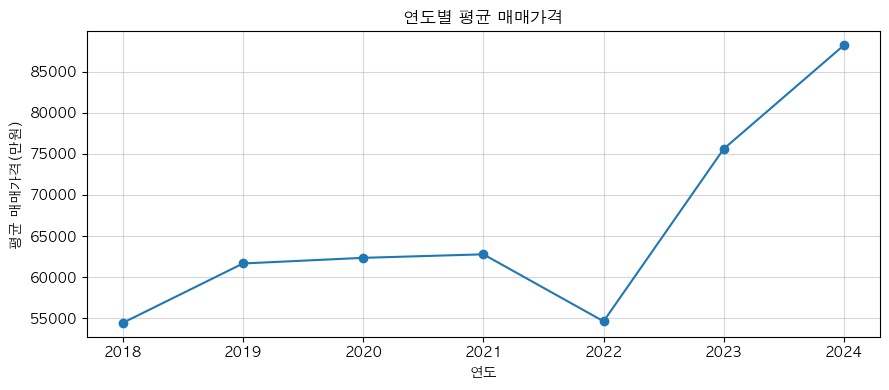

In [89]:
# 1. 연도별 평균 매매가격

plt.figure(figsize=(9, 4))

plt.plot(seoul_year_summary["접수연도"], seoul_year_summary["물건금액(만원)"], marker = "o", linestyle = "-")

plt.title("연도별 평균 매매가격", fontsize = 12)
plt.xlabel("연도")
plt.ylabel("평균 매매가격(만원)")
plt.grid(True, alpha = 0.5)
plt.tight_layout()

plt.show()

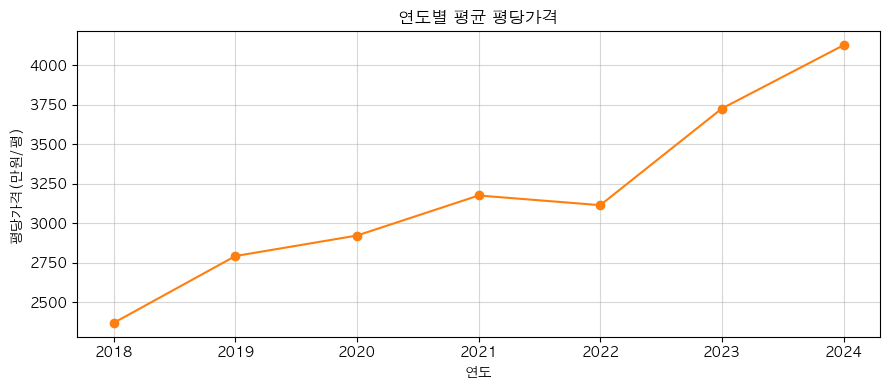

In [90]:
# 2. 연도별 평균 평당가격

plt.figure(figsize=(9, 4))

plt.plot(seoul_year_summary["접수연도"], seoul_year_summary["평당가격"], marker = "o", linestyle = "-", color = "tab:orange")

plt.title("연도별 평균 평당가격", fontsize = 12)
plt.xlabel("연도")
plt.ylabel("평당가격(만원/평)")
plt.grid(True, alpha = 0.5)
plt.tight_layout()

plt.show()

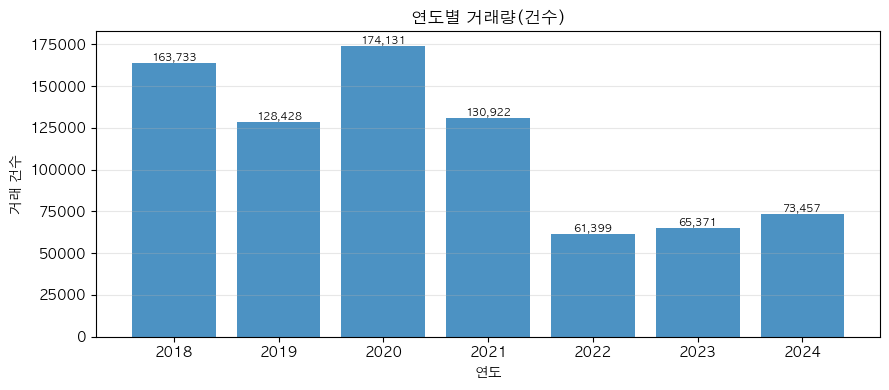

In [91]:
# 3. 연도별 거래량(건수)

plt.figure(figsize=(9, 4))

plt.bar(seoul_year_summary["접수연도"], seoul_year_summary["거래량"], alpha = 0.8)

plt.title("연도별 거래량(건수)", fontsize = 12)
plt.xlabel("연도")
plt.ylabel("거래 건수")

for i, v in enumerate(seoul_year_summary["거래량"]):
    plt.text(seoul_year_summary["접수연도"][i], v, f"{v:,}", ha = 'center', va = 'bottom', fontsize = 7.5)
plt.grid(axis = "y", alpha = 0.3)
plt.tight_layout()

plt.show()

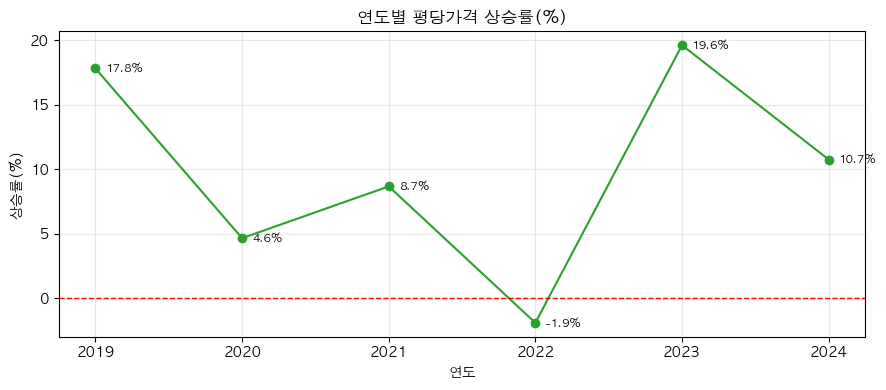

In [92]:
# 4. 연도별 평당가격 상승률(%)
plt.figure(figsize=(9, 4))

plt.plot(seoul_year_summary["접수연도"], seoul_year_summary["상승률(%)"],
         marker="o", linestyle="-", color="tab:green")

plt.axhline(0, color = "red", linestyle = "--", linewidth = 1)

plt.title("연도별 평당가격 상승률(%)", fontsize=12)
plt.xlabel("연도")
plt.ylabel("상승률(%)")
plt.grid(True, alpha = 0.3)

os = -0.5
os_1 = 0.07
for i, v in enumerate(seoul_year_summary["상승률(%)"]):
    if pd.notna(v):
        plt.text(seoul_year_summary["접수연도"][i] + os_1, v + os, f"{v:.1f}%", ha = "left", va = "bottom", fontsize = 8)

plt.tight_layout()
plt.show()